In [3]:
# Core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

# Scikit-learn for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Advanced libraries
import xgboost as xgb
import shap
import optuna
import folium
from geopy.distance import great_circle

# Settings for reproducibility and display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
np.random.seed(42)



In [8]:
import pandas as pd
import requests

# 1. Download and save the file locally first
url = "https://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2025-06-27/data/listings.csv.gz"
response = requests.get(url)
with open('listings.csv.gz', 'wb') as f:
    f.write(response.content)

# 2. Now load it from your hard drive
df_raw = pd.read_csv('listings.csv.gz', compression='gzip', low_memory=False)

In [9]:
# Get a first impression of the data
print(f"Dataset shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df_raw.head(3)

Dataset shape: (22684, 79)
Memory usage: 92.22 MB


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,29118,https://www.airbnb.com/rooms/29118,20250627030604,2025-06-30,city scrape,Best Location in Cool Istedgade,NaN,NaN,https://a0.muscache.com/pictures/b83c7003-367a...,125230,https://www.airbnb.com/users/show/125230,Nana,2010-05-15,"Copenhagen, Denmark",I have a Master of Arts in Musicology and I wo...,within a few hours,100%,50%,f,https://a0.muscache.com/im/users/125230/profil...,https://a0.muscache.com/im/users/125230/profil...,Vesterbro,1.0,1.0,"['email', 'phone']",t,t,NaN,Vesterbro-Kongens Enghave,NaN,55.670230,12.555040,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Backyard"", ""Dining table"", ""Essentials"", ""Pa...",$900.00,7,14,5.0,5.0,14.0,14.0,5.0,14.0,NaN,t,6,7,17,18,2025-06-30,27,0,0,18,1,0,0.0,2010-06-17,2024-03-31,4.85,4.67,4.67,4.89,5.00,4.83,4.72,NaN,f,1,1,0,0,0.15
1,31094,https://www.airbnb.com/rooms/31094,20250627030604,2025-07-01,previous scrape,"Beautiful, spacious, central, renovated Penthouse","Welcome to our home, we hope you will enjoy Wo...","What else is nearby?<br />To be honest, We thi...",https://a0.muscache.com/pictures/miso/Hosting-...,129976,https://www.airbnb.com/users/show/129976,Ebbe,2010-05-22,"Copenhagen, Denmark","Hi and welcome. My name is Ebbe, I am a medica...",NaN,NaN,NaN,f,https://a0.muscache.com/im/users/129976/profil...,https://a0.muscache.com/im/users/129976/profil...,Vesterbro,1.0,1.0,"['email', 'phone']",t,t,"Copenhagen, Capital Region of Denmark, Denmark",Vesterbro-Kongens Enghave,NaN,55.666602,12.555283,Entire condo,Entire home/apt,6,NaN,1.5 baths,4.0,NaN,"[""Coffee maker: drip coffee maker, espresso ma...",NaN,3,10,3.0,3.0,10.0,10.0,3.0,10.0,NaN,t,0,0,0,0,2025-07-01,19,0,0,0,0,0,NaN,2010-08-16,2022-08-22,4.88,4.82,4.88,4.87,4.82,4.80,4.53,NaN,f,1,1,0,0,0.10
2,32379,https://www.airbnb.com/rooms/32379,20250627030604,2025-06-28,city scrape,"155 m2 artist flat on Vesterbro, with 2 bathrooms",You enter a narrow entrance and feel the good ...,"Værnedamsvej area is super hip area, we call i...",https://a0.muscache.com/pictures/miso/Hosting-...,140105,https://www.airbnb.com/users/show/140105,Lise,2010-06-07,"Copenhagen, Denmark",As profession - Set and Costumedesigner for Av...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/140105/profil...,https://a0.muscache.com/im/users/140105/profil...,Vesterbro,3.0,4.0,"['email', 'phone']",t,t,"Copenhagen, V, Denmark",Vesterbro-Kongens Enghave,NaN,55.672638,12.552493,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,3.0,"[""Dedicated workspace"", ""Hot water"", ""Iron"", ""...","$2,282.00",3,5,3.0,3.0,5.0,5.0,3.0,5.0,NaN,t,0,4,

Initial Data Quality Assessment

In [10]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22684 entries, 0 to 22683
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22684 non-null  int64  
 1   listing_url                                   22684 non-null  object 
 2   scrape_id                                     22684 non-null  int64  
 3   last_scraped                                  22684 non-null  object 
 4   source                                        22684 non-null  object 
 5   name                                          22684 non-null  object 
 6   description                                   22070 non-null  object 
 7   neighborhood_overview                         8225 non-null   object 
 8   picture_url                                   22684 non-null  object 
 9   host_id                                       22684 non-null 

A heatmap can visualize the extent of missing data across the entire dataset.

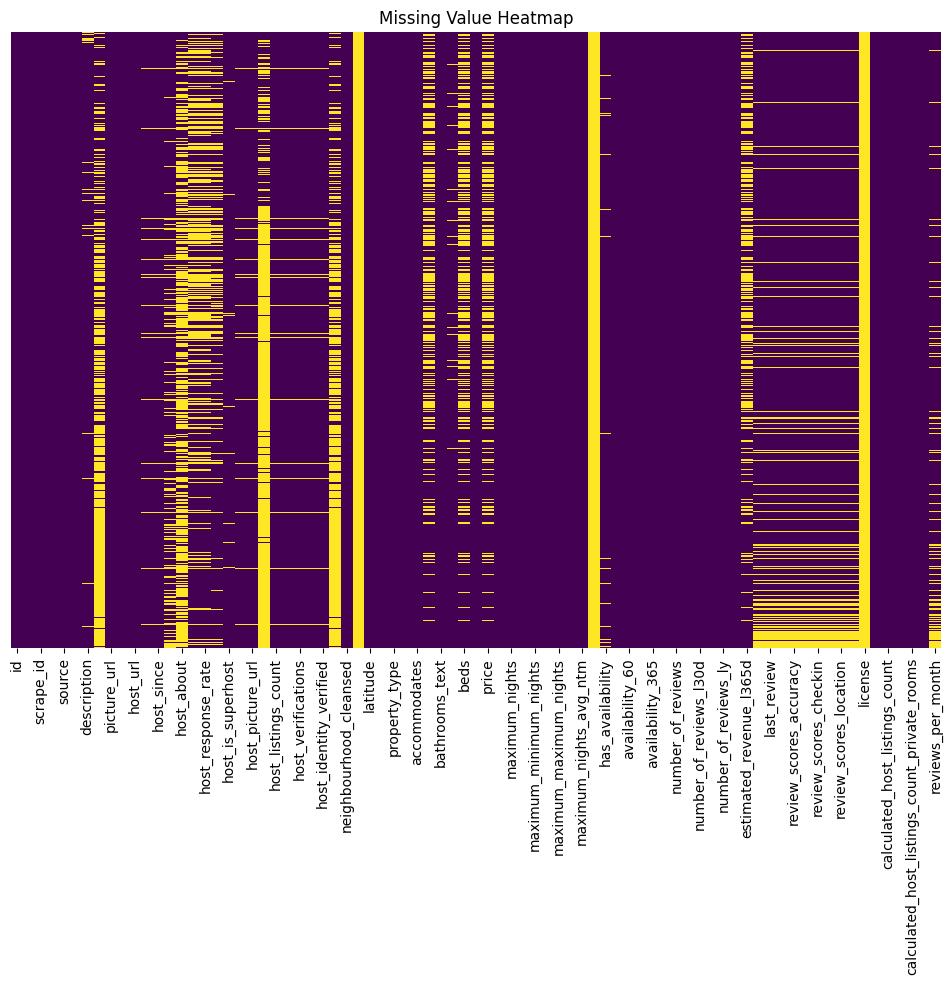

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

Many columns are almost entirely empty or contain descriptive text not immediately useful for modeling. We'll need to be selective about which features to pursue.

Target Variable Cleaning (price)

Our target variable price is an object type because it contains currency symbols ($) and commas. Although the currency is Danish Krone (DKK), it's formatted with a dollar sign. We must convert this into a clean numeric format.

In [12]:
# Make a copy to avoid modifying the original raw data
df = df_raw.copy()

# A more robust function to clean the price column
def clean_price(price_series):
    """
    Cleans a pandas Series of price strings.
    - Handles NaN values gracefully.
    - Removes currency symbols and commas.
    - Converts the result to a numeric type, coercing errors.
    """
    # Use the .str accessor which automatically skips NaN values
    # The regex '[$,]' matches either a '$' or a ','
    cleaned_series = price_series.str.replace(r'[$,]', '', regex=True)
    
    # Convert to numeric, turning any values that can't be converted into NaN
    return pd.to_numeric(cleaned_series, errors='coerce')

df['price_dkk'] = clean_price(df['price'])

# Verify the result by checking the dtype and for any remaining NaNs
print("Cleaned price column data type:", df['price_dkk'].dtype)
print(f"Number of null prices after cleaning: {df['price_dkk'].isnull().sum()}")
df[['price', 'price_dkk']].head(10)

Cleaned price column data type: float64
Number of null prices after cleaning: 8853


,price,price_dkk
0,$900.00,900.0
1,NaN,NaN
2,"$2,282.00",2282.0
3,$589.00,589.0
4,"$2,223.00",2223.0
5,"$1,760.00",1760.0
6,$470.00,470.0
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


Outlier Analysis

Extreme price values (e.g., placeholder values like 0 or luxury listings costing tens of thousands) can skew our model. We'll use winsorization—capping extreme values at a given percentile—to create a more stable target.

In [13]:
# Describe the price distribution before handling outliers
print("Price distribution before outlier handling:")
print(df['price_dkk'].describe())

Price distribution before outlier handling:
count     13831.000000
mean       1417.890102
std        1556.549805
min         136.000000
25%         900.000000
50%        1182.000000
75%        1622.000000
max      100000.000000
Name: price_dkk, dtype: float64


In [14]:
# Winsorize: Cap prices at the 1st and 99th percentiles
lower_bound = df['price_dkk'].quantile(0.01)
upper_bound = df['price_dkk'].quantile(0.99)
df['price_dkk'] = df['price_dkk'].clip(lower=lower_bound, upper=upper_bound)

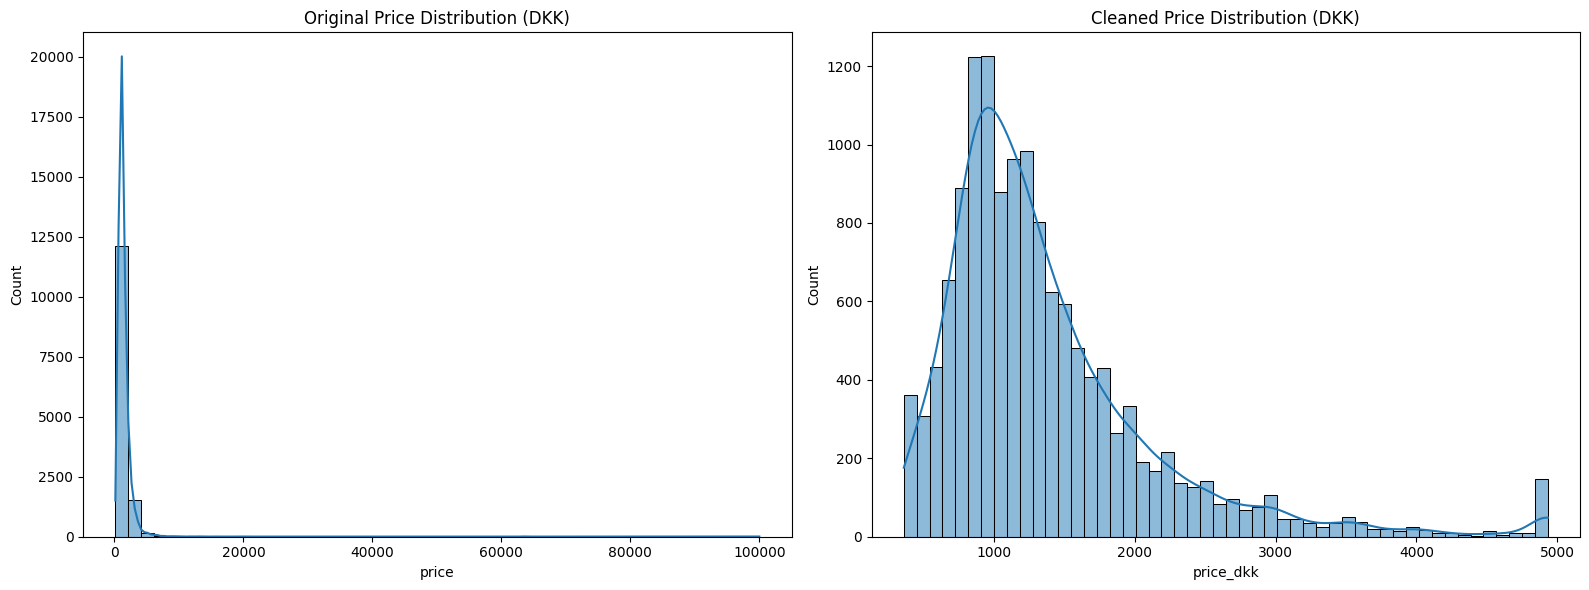

In [15]:
# Plot before and after distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(clean_price(df_raw['price']), ax=axes[0], bins=50, kde=True).set_title("Original Price Distribution (DKK)")
sns.histplot(df['price_dkk'], ax=axes[1], bins=50, kde=True).set_title("Cleaned Price Distribution (DKK)")
plt.tight_layout()
plt.show()

By cleaning the price data, we've created a more stable target variable. The original data had a maximum price over 70,000 DKK, which was likely an outlier. Our cleaned distribution is more focused on the core market, allowing our model to learn more generalizable patterns.

Core Features Processing

We will now process a selection of promising features.

Bathroom Text Parsing
The bathrooms_text column is descriptive (e.g., "1.5 baths", "Half-bath"). We can extract the numeric value using regular expressions.

In [16]:
def parse_bathrooms(text_series):
    """
    Parses a text series containing bathroom information into a numeric format.
    Handles values like '1.5 baths', '1 shared bath', and 'Half-bath'.
    """
    # Work with a copy to ensure we are modifying strings
    s = text_series.copy().astype(str).str.lower()

    # Step 1: Replace any string containing 'half-bath' with the numeric string '0.5'.
    # This handles 'Half-bath', 'Private half-bath', 'Shared half-bath', etc.
    s[s.str.contains('half-bath', na=False)] = '0.5'

    # Step 2: Extract the first floating point number found in the remaining strings.
    # The .str.extract() method returns a DataFrame, so we select the first column [0].
    numeric_strings = s.str.extract(r'(\d+\.?\d*)')[0]
    
    # Step 3: Convert the resulting series of strings to numbers.
    # 'errors='coerce'' ensures that any non-numeric results become NaN.
    return pd.to_numeric(numeric_strings, errors='coerce')

df['bathrooms_numeric'] = parse_bathrooms(df['bathrooms_text'])

# Let's run more comprehensive checks to be sure
print("Parsing examples:")
print(f"'1.5 baths' -> {parse_bathrooms(pd.Series(['1.5 baths'])).iloc[0]}")
print(f"'Half-bath' -> {parse_bathrooms(pd.Series(['Half-bath'])).iloc[0]}")
print(f"'2 shared baths' -> {parse_bathrooms(pd.Series(['2 shared baths'])).iloc[0]}")

# The original check should now pass, plus a new one for our special case
assert df[df['bathrooms_text'] == '1.5 baths']['bathrooms_numeric'].iloc[0] == 1.5
assert df[df['bathrooms_text'] == 'Shared half-bath']['bathrooms_numeric'].iloc[0] == 0.5

print("\nAssertions passed successfully!")

Parsing examples:
'1.5 baths' -> 1.5
'Half-bath' -> 0.5
'2 shared baths' -> 2

Assertions passed successfully!


Boolean Feature Conversion

Columns like host_is_superhost and instant_bookable are stored as 't'/'f'. We convert them to a binary 0/1 format.

In [17]:
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0})

Geographic Feature Engineering

Distance to City Center
Let's calculate the distance of each listing to a central landmark, City Hall Square.

In [18]:
cph_center = (55.676098, 12.568337) # Rådhuspladsen coordinates

def calculate_distance_to_center(df_geo):
    lat = pd.to_numeric(df_geo['latitude'], errors='coerce')
    lon = pd.to_numeric(df_geo['longitude'], errors='coerce')
    locations = list(zip(lat, lon))
    distances = [
        great_circle(loc, cph_center).kilometers if not (np.isnan(loc[0]) or np.isnan(loc[1])) else np.nan
        for loc in locations
    ]
    return distances

df['distance_to_center_km'] = calculate_distance_to_center(df)

Interactive Map of Listings

A folium map helps visualize the geographic distribution and price clusters.

In [ ]:
# Create a sample to avoid overloading the map
df_sample = df.sample(n=1000, random_state=42)

# Create a map centered on Copenhagen
map_cph = folium.Map(location=[55.6761, 12.5683], zoom_start=12)

# Add points to the map
for idx, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='purple',
        fill=True,
        fill_color='purple',
        fill_opacity=0.6,
        popup=f"Price: {row['price_dkk']:.0f} DKK"
    ).add_to(map_cph)



In [27]:
map_cph.save("copenhagen_rentals.html")

In [28]:
from IPython.display import display

# This will render the interactive map right below your code cell
display(map_cph)

Temporal Features

How long a listing has been active can be an indicator of its quality and host experience.

In [29]:
# Convert date columns to datetime objects
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_scraped'] = pd.to_datetime(df['last_scraped'], errors='coerce')

# Calculate days since the first review
# We use the latest scrape date as our 'today' for consistency
latest_date = df['last_scraped'].max()
df['days_since_first_review'] = (latest_date - df['first_review']).dt.days

Train-Test Split Strategy

In [30]:
# Final feature selection for our model
# We select a mix of numeric, categorical, and boolean features.
numeric_features = [
    'accommodates', 'bathrooms_numeric', 'bedrooms', 'beds',
    'review_scores_rating', 'distance_to_center_km', 'days_since_first_review'
]
categorical_features = ['neighbourhood_cleansed', 'room_type', 'property_type']
boolean_features = ['host_is_superhost', 'instant_bookable']

# Combine all features
all_features = numeric_features + categorical_features + boolean_features
target = 'price_dkk'

# Drop rows where our target or key features are missing
df_model = df[all_features + [target]].dropna().copy()

X = df_model[all_features]
y = df_model[target]

# Let's check the dtypes of our final feature set before splitting
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11486 entries, 0 to 22502
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   accommodates             11486 non-null  int64  
 1   bathrooms_numeric        11486 non-null  float64
 2   bedrooms                 11486 non-null  float64
 3   beds                     11486 non-null  float64
 4   review_scores_rating     11486 non-null  float64
 5   distance_to_center_km    11486 non-null  float64
 6   days_since_first_review  11486 non-null  float64
 7   neighbourhood_cleansed   11486 non-null  object 
 8   room_type                11486 non-null  object 
 9   property_type            11486 non-null  object 
 10  host_is_superhost        11486 non-null  float64
 11  instant_bookable         11486 non-null  int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 1.1+ MB


In [31]:
# First split: 70% train, 30% temp (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: Split the temp set into 50% validation, 50% test (15% of original each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [32]:
# Verify the shapes of our datasets
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

Training set shape:   (8040, 12)
Validation set shape: (1723, 12)
Test set shape:       (1723, 12)


Preprocessing Pipeline

In [34]:
# Create the numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create the categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Assembling the ColumnTransformer

In [35]:
# The ColumnTransformer applies specified transformers to columns of a DataFrame.
# The structure is a list of tuples: (name, transformer_object, list_of_columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bool', 'passthrough', boolean_features)
    ],
    remainder='drop' # Drop any columns not specified in our feature lists
)

Model Development

In [36]:
# Create the full pipeline with the preprocessor and a dummy model
dummy_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', DummyRegressor(strategy='mean'))])

# Train and evaluate the baseline
dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_val)
rmse_dummy = np.sqrt(mean_squared_error(y_val, y_pred_dummy))

print(f"Baseline (Mean Predictor) RMSE: {rmse_dummy:,.2f} DKK")

Baseline (Mean Predictor) RMSE: 739.26 DKK


Linear Model

In [37]:
# Create a Ridge regression pipeline
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', RidgeCV(alphas=np.logspace(-3, 3, 7)))])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_val)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))

print(f"Ridge Regression RMSE: {rmse_ridge:,.2f} DKK")

Ridge Regression RMSE: 510.68 DKK


Tree-Based Models

In [38]:
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf:,.2f} DKK")

Random Forest RMSE: 514.82 DKK


In [39]:
# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"XGBoost RMSE: {rmse_xgb:,.2f} DKK")

XGBoost RMSE: 514.57 DKK


Hyperparameter Tuning with Optuna

In [40]:
# Define the objective function for Optuna
# We pass the pre-split data to the function
def objective(trial, X_train, y_train, X_val, y_val):
    # Fit the preprocessor on the training data ONLY
    preprocessor.fit(X_train)
    X_train_transformed = preprocessor.transform(X_train)
    X_val_transformed = preprocessor.transform(X_val)
    
    # Define the search space for hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Create and train the model
    model = RandomForestRegressor(**params)
    model.fit(X_train_transformed, y_train)
    
    # Evaluate on the validation set
    y_pred = model.predict(X_val_transformed)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    return rmse

# Create a study and optimize (run a small number of trials for the workshop)
study = optuna.create_study(direction='minimize')
# Note: For a real project, n_trials would be much larger (e.g., 50-100).
study.optimize(lambda trial: objective(trial, X_train, y_train, X_val, y_val), n_trials=20)

print(f"Best trial RMSE: {study.best_value:.2f} DKK")
print("Best hyperparameters:", study.best_params)

[I 2026-04-07 20:57:13,492] A new study created in memory with name: no-name-ab43b92f-a493-426d-bef8-6801a1ed7914
[I 2026-04-07 20:57:14,614] Trial 0 finished with value: 506.27128135017443 and parameters: {'n_estimators': 395, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 7}. Best is trial 0 with value: 506.27128135017443.
[I 2026-04-07 20:57:15,700] Trial 1 finished with value: 506.9265875476515 and parameters: {'n_estimators': 402, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 9}. Best is trial 0 with value: 506.27128135017443.
[I 2026-04-07 20:57:16,738] Trial 2 finished with value: 505.6975106942113 and parameters: {'n_estimators': 357, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 2 with value: 505.6975106942113.
[I 2026-04-07 20:57:17,455] Trial 3 finished with value: 509.11583909617474 and parameters: {'n_estimators': 188, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 2 with value

Best trial RMSE: 505.34 DKK
Best hyperparameters: {'n_estimators': 492, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 5}


Final Model Training and Performance Metrics

In [41]:
# Get the best hyperparameters from the Optuna study
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# Create the final, optimized pipeline
final_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', RandomForestRegressor(**best_params))])

# Combine train and validation sets for final training
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Train on the full training data
final_model_pipeline.fit(X_train_full, y_train_full)

# Evaluate on the unseen test set
y_pred_final = final_model_pipeline.predict(X_test)

In [42]:
# Calculate final performance metrics
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mape_final = mean_absolute_percentage_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"Final Model Performance on Test Set:")
print(f"RMSE: {rmse_final:,.2f} DKK")
print(f"MAPE: {mape_final:.2%}")
print(f"R² Score: {r2_final:.2f}")

Final Model Performance on Test Set:
RMSE: 533.83 DKK
MAPE: 26.11%
R² Score: 0.53


Residual Analysis

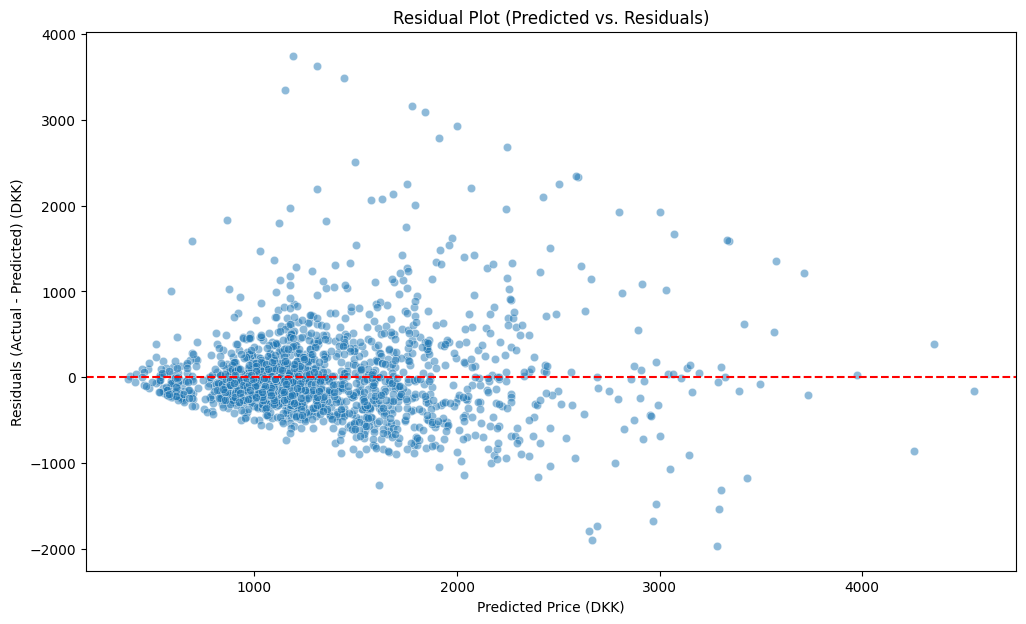

In [43]:
residuals = y_test - y_pred_final

plt.figure(figsize=(12, 7))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Predicted vs. Residuals)")
plt.xlabel("Predicted Price (DKK)")
plt.ylabel("Residuals (Actual - Predicted) (DKK)")
plt.show()

Model Interpretability with SHAP

In [44]:
# 1. Get the fitted preprocessor from the final pipeline
fitted_preprocessor = final_model_pipeline.named_steps['preprocessor']

# 2. Transform the test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# 3. Extract feature names after one-hot encoding
# Access the 'cat' transformer, then its 'onehot' step, then get the feature names
cat_features_out = fitted_preprocessor.named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(categorical_features)

# 4. Combine all feature names in the correct order
feature_names = numeric_features + list(cat_features_out) + boolean_features

In [45]:
# Create a SHAP explainer for tree-based models
explainer = shap.TreeExplainer(final_model_pipeline.named_steps['regressor'])
shap_values = explainer.shap_values(X_test_transformed)

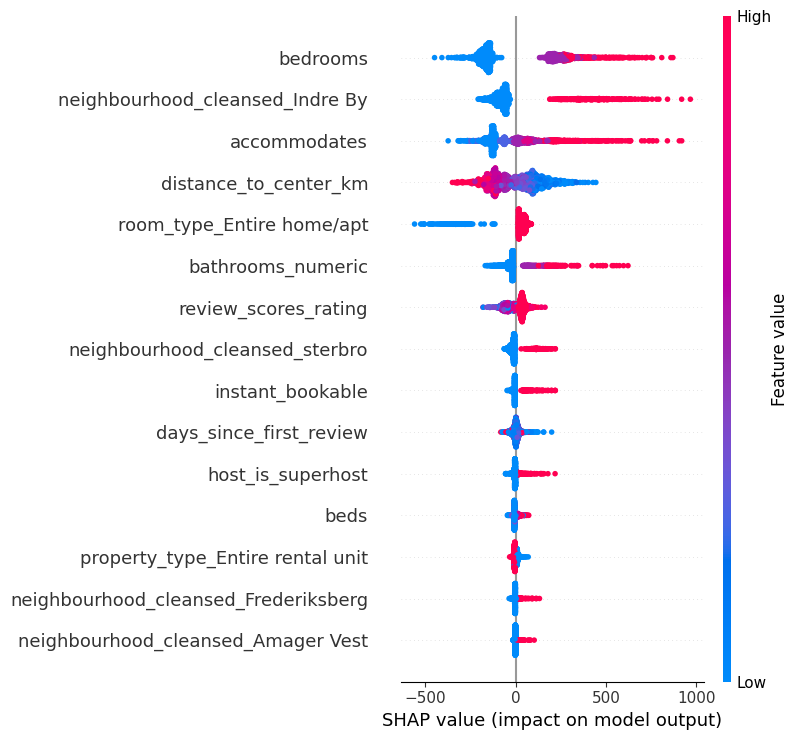

In [46]:
# Create the summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=15)

📈 Business Recommendations & Model Insights

Our model is not just a technical artifact; it's a strategic tool for data-driven decision-making in the Copenhagen rental market.

---

### 🔍 Key Insights

* **Core Amenities Drive Value:** The number of bathrooms, bedrooms, and guest capacity (`accommodates`) are the most critical price drivers. 
    > **Action:** Investments in adding or upgrading these facilities are likely to yield the highest ROI.
* **Location is Non-Negotiable:** Proximity to the city center is a massive price factor. 
    > **Action:** For listings further out, marketing should shift focus to secondary value propositions like "quiet surroundings" or "extra space."
* **Neighborhood Premiums:** Districts like **Indre By** and **Vesterbro** command a significant price floor.
* **Property Type Impact:** "Entire home/apt" listings are priced significantly higher than private or shared rooms. Our model helps quantify exactly how much that premium is worth.

---

### 🚀 Deployment Considerations

1.  **Internal Pricing Tool:** This model can be deployed as a baseline estimator for portfolio managers to evaluate the potential of new properties before acquisition.
2.  **Dynamic Pricing Integration:** The engine can be enhanced with seasonality data (holidays, festivals) to move from static estimates to real-time dynamic pricing.
3.  **Model Governance:** The Copenhagen market is fluid. We recommend **quarterly retraining** to account for market shifts and monitoring for "feature drift" to ensure accuracy remains high.

---

### 🛠️ Limitations & Future Work

| Area | Potential Enhancement |
| :--- | :--- |
| **Granular Amenities** | Parsing the full `amenities` string to identify high-value tags like "Balcony," "EV Charger," or "Sauna." |
| **Computer Vision** | Integrating image analysis to score property photos on quality and modern aesthetic. |
| **Temporal Data** | Incorporating time-series data to capture seasonal spikes (e.g., Midsummer or Christmas markets). |
| **Sentiment Analysis** | Processing guest reviews to see if "Superhost" status or specific positive keywords correlate with higher price ceilings. |